In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from matplotlib import font_manager

# --- 1. スタイル設定 ---
font_path = "/work/fonts/arialbd.ttf"

if not Path(font_path).exists():
    raise FileNotFoundError(f"Font file not found: {font_path}")

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]

plt.rcParams.update({
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.format": "svg",
    "savefig.bbox": "tight",
})

# --- 2. 共通の作図・保存ヘルパー ---
FIGSIZE = (10, 5)
SVG_DIR = Path("/work/robomimic/svg")

def new_figure(figsize=FIGSIZE):
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax

def save_svg(fig, filename, out_dir=SVG_DIR):
    out_dir = Path(out_dir)
    if not out_dir.is_absolute():
        out_dir = SVG_DIR / out_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    if out_path.suffix.lower() != ".svg":
        out_path = out_path.with_suffix(".svg")
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")

In [2]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/LNN/6-6-6/3bit/99.9_1/gaussian"
TOP_K = 10

def extract_gaussian(path):
    m = re.search(r"gaussian([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/u{unit}/gaussian*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        g = extract_gaussian(f)
        if g is None:
            continue
                
        df = pd.read_csv(f)

        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()
        results.append({
            "unit": unit,
            "gaussian": g,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
display(results_df)


,unit,gaussian,mean_success,std_success
0,64,0.00,0.956,0.021705
1,64,0.01,0.934,0.038064
2,64,0.02,0.851,0.061183
3,64,0.03,0.728,0.109626
4,64,0.04,0.565,0.193692
5,64,0.05,0.379,0.229272
6,64,0.06,0.207,0.194082
7,64,0.07,0.109,0.132367
8,64,0.08,0.047,0.091779
9,128,0.00,0.993,0.004830


Saved: /work/robomimic/svg/proposal/3bit/99.9_1/gaussian.svg


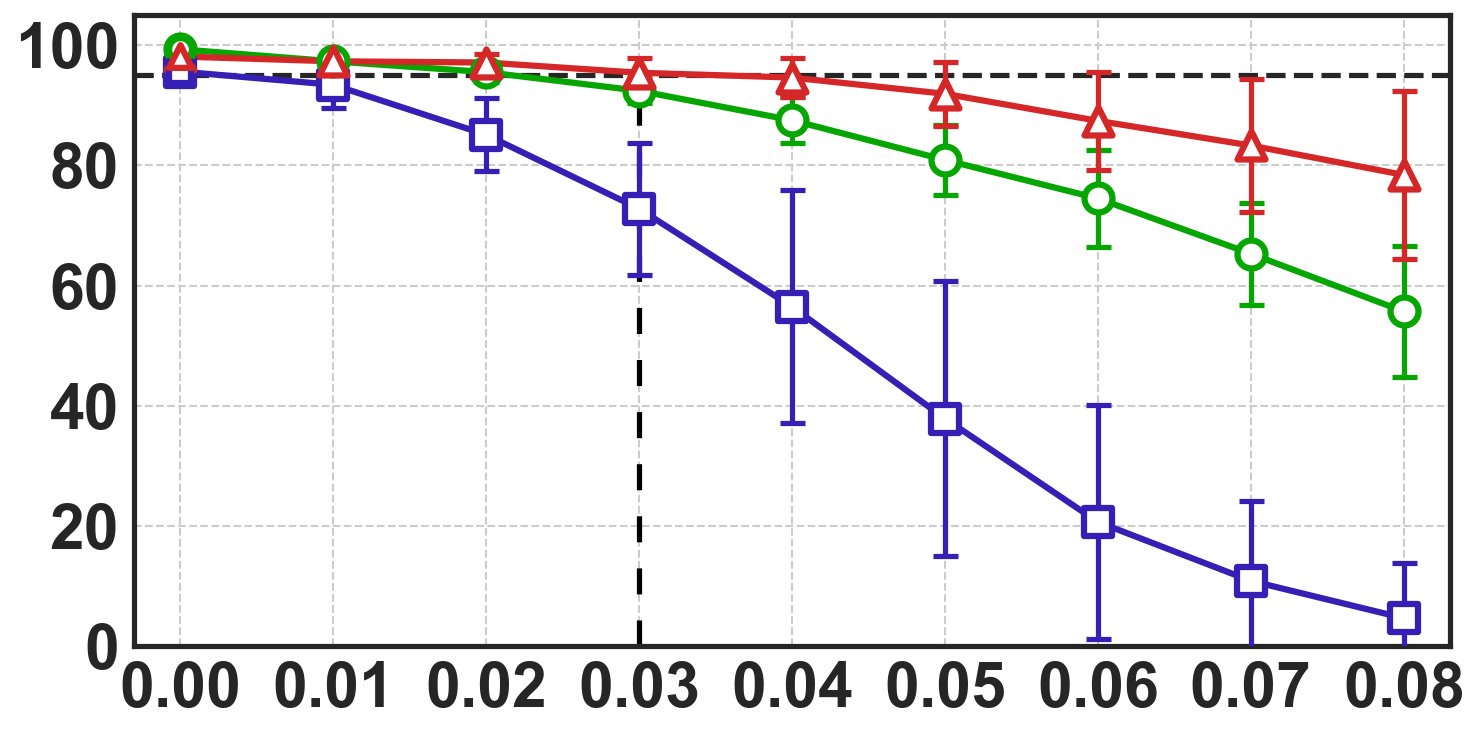

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

fig, ax = new_figure()

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    df_u = results_df[results_df["unit"] == unit].sort_values("gaussian")

    if 0.0 in df_u["gaussian"].values:
        y0 = df_u.loc[df_u["gaussian"] == 0.0, "mean_success"].values[0]
        ax.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    ax.plot(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    ax.scatter(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    ax.errorbar(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
    )

ax.set_ylim(0, 105)
ax.set_xlim(-0.003, 0.083)
ax.set_xticks(np.arange(0.0, 0.09, 0.02))
ax.set_yticks(np.arange(0, 101, 20))

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

xs = np.linspace(-0.003, 0.083, 400)
ys = np.full_like(xs, 95, dtype=float)
yt = np.linspace(0, 95, 400)
xt = np.full_like(yt, 0.03, dtype=float)

ax.plot(
    xs, ys,
    color="black",
    linestyle="--",
    linewidth=2.5,
    alpha=0.85,
    zorder=1,
    clip_on=False,
)

ax.plot(
    xt, yt,
    color="black",
    linestyle=(0, (5, 5)),
    linewidth=2.5,
    zorder=2,
    clip_on=False,
)

ax.grid(which="major", linestyle="--", linewidth=1.0, zorder=-3)
ax.grid(which="minor", linestyle="--", linewidth=0.8, zorder=-4)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

fig.tight_layout()
save_svg(fig, "gaussian.svg", "proposal/3bit/99.9_1")
plt.show()


In [4]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/LNN/6-6-6/3bit/99.9_1/shift"
TOP_K = 10

def extract_shift(path):
    m = re.search(r"shift([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []
skipped_files = []

for unit in units:
    pattern = f"{base_path}/u{unit}/shift*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        s = extract_shift(f)
        if s is None:
            continue

        try:
            df = pd.read_csv(f)
        except pd.errors.EmptyDataError:
            skipped_files.append((f, "empty csv"))
            continue
        except Exception as e:
            skipped_files.append((f, f"read error: {e}"))
            continue

        if df.empty:
            skipped_files.append((f, "empty dataframe"))
            continue
        if "success_rate" not in df.columns:
            skipped_files.append((f, "missing success_rate column"))
            continue

        topk = df.nlargest(TOP_K, "success_rate")
        if topk.empty:
            skipped_files.append((f, "topk is empty"))
            continue

        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()
        if s * 1000 % 10 == 0:
            results.append({
                "unit": unit,
                "shift": s,
                "mean_success": mean_success,
                "std_success": std_success
            })

results_df_shift = pd.DataFrame(results)
display(results_df_shift)

if skipped_files:
    print(f"[shift] skipped files: {len(skipped_files)}")
    for p, reason in skipped_files[:10]:
        print(f"- {p}: {reason}")

,unit,shift,mean_success,std_success
0,64,0.00,0.956,0.021705
1,64,0.01,0.949,0.021318
2,64,0.02,0.933,0.030930
3,64,0.03,0.891,0.044335
4,64,0.04,0.874,0.063281
5,64,0.05,0.816,0.093119
6,64,0.06,0.760,0.128496
7,64,0.07,0.708,0.155835
8,64,0.08,0.650,0.191485
9,128,0.00,0.985,0.009718


Saved: /work/robomimic/svg/proposal/3bit/99.9_1/shift.svg


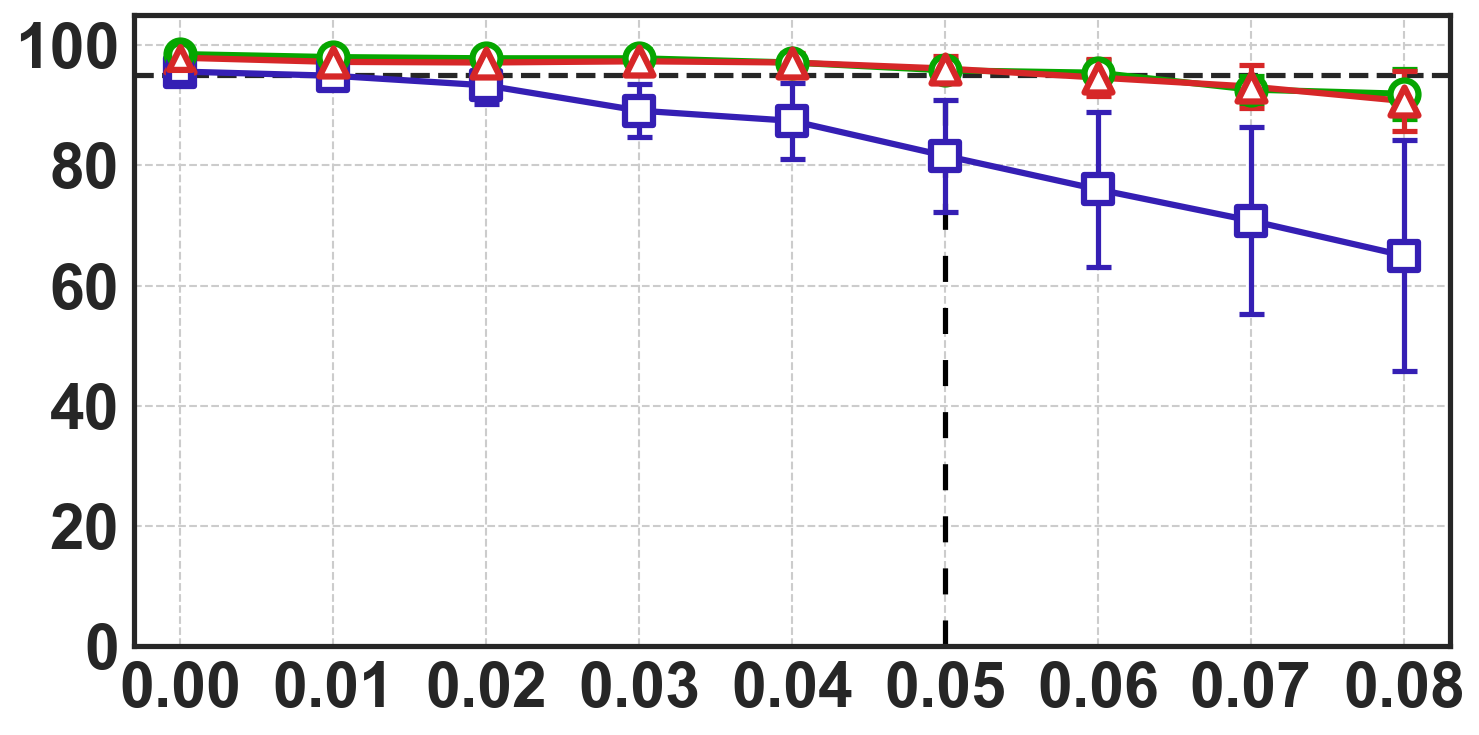

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

fig, ax = new_figure()

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    df_u = results_df_shift[results_df_shift["unit"] == unit].sort_values("shift")

    if 0.0 in df_u["shift"].values:
        y0 = df_u.loc[df_u["shift"] == 0.0, "mean_success"].values[0]
        ax.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    ax.plot(
        df_u["shift"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    ax.scatter(
        df_u["shift"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    ax.errorbar(
        df_u["shift"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
    )

ax.set_ylim(0, 105)
ax.set_xlim(-0.003, 0.083)
ax.set_xticks(np.arange(0.0, 0.09, 0.02))
ax.set_yticks(np.arange(0, 101, 20))

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

xs = np.linspace(-0.003, 0.083, 400)
ys = np.full_like(xs, 95, dtype=float)

ax.plot(
    xs, ys,
    color="black",
    linestyle="--",
    linewidth=2.5,
    alpha=0.85,
    zorder=1,
    clip_on=False,
)
yt = np.linspace(0, 95, 400)
xt = np.full_like(yt, 0.05, dtype=float)

ax.plot(
    xt, yt,
    color="black",
    linestyle=(0, (5, 5)),
    linewidth=2.5,
    zorder=2,
    clip_on=False,
)
ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

fig.tight_layout()
save_svg(fig, "shift.svg", "proposal/3bit/99.9_1")
plt.show()
